# Notebook 02: Time-Aware Feature Engineering & Leakage Prevention

## Executive Summary
This notebook constructs the historical **Feature Mart** (`fact_player_features`) used by the Expected Points ($xP$) engine.

### Core Engineering Principles:
1. **Strict Data Leakage Prevention**: Predictions for Gameweek $N$ must exclusively rely on data available up to Gameweek $N-1$. All rolling aggregations are explicitly shifted using `.shift(1)`.
2. **Sub-Appearance Noise Reduction (Per-90 Windowing)**: Rather than averaging game-by-game Per-90 statistics (which produces massive variance on 5-minute substitute appearances), we compute ratio-of-sums:
   $$\text{Rolling Stat}_{90} = \frac{\sum_{i=N-k}^{N-1} \text{Stat}_i}{\sum_{i=N-k}^{N-1} \text{Minutes}_i} \times 90$$
3. **Multi-Window Signal Capture**: Computes short-term (3 GWs) and medium-term (5 GWs) rolling dynamics for player form and expected minutes ($\hat{xMin}$).

In [1]:
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DB_PATH = "../data/fpl.db"

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Database not found at {DB_PATH}. Run ingest_fpl_data.py first.")

conn = sqlite3.connect(DB_PATH)
print("Connected to SQLite database successfully!")

Connected to SQLite database successfully!


## 1. Extracting Historical Gameweek Logs

We query player appearance logs ordered chronologically by `player_id` and `round` (GW).

In [3]:
query_history = """
SELECT 
    f.player_id,
    p.web_name AS player_name,
    p.position_id,
    CASE p.position_id 
        WHEN 1 THEN 'GKP'
        WHEN 2 THEN 'DEF'
        WHEN 3 THEN 'MID'
        WHEN 4 THEN 'FWD'
    END AS position,
    t.short_name AS team_name,
    f.fixture_id,
    f.was_home,
    f.round AS gw,
    f.minutes,
    f.starts,
    f.expected_goals AS xG,
    f.expected_assists AS xA,
    f.saves,
    f.defensive_contribution AS defcon
FROM fact_player_gameweek f
JOIN dim_players p ON f.player_id = p.player_id
JOIN fact_fixtures fix ON f.fixture_id = fix.fixture_id
JOIN dim_teams t ON t.team_id = CASE WHEN f.was_home = 1 THEN fix.home_team_id ELSE fix.away_team_id END
ORDER BY f.player_id, f.round;
"""

df = pd.read_sql(query_history, conn)
print(f"Loaded {len(df)} historical player-gameweek records.")
df.head(10)

Loaded 1890 historical player-gameweek records.


,player_id,player_name,position_id,position,team_name,fixture_id,was_home,gw,minutes,starts,xG,xA,saves,defcon
0,1,Raya,1,GKP,ARS,1,1,1,90,1,0.00,0.00,1,0
1,1,Raya,1,GKP,ARS,20,0,2,90,1,0.00,0.00,0,0
2,1,Raya,1,GKP,ARS,29,1,3,90,1,0.00,0.01,4,0
3,2,Arrizabalaga,1,GKP,ARS,1,1,1,0,0,0.00,0.00,0,0
4,2,Arrizabalaga,1,GKP,ARS,20,0,2,0,0,0.00,0.00,0,0
5,2,Arrizabalaga,1,GKP,ARS,29,1,3,0,0,0.00,0.00,0,0
6,3,Meslier,1,GKP,ARS,1,1,1,0,0,0.00,0.00,0,0
7,3,Meslier,1,GKP,ARS,20,0,2,0,0,0.00,0.00,0,0
8,3,Meslier,1,GKP,ARS,29,1,3,0,0,0.00,0.00,0,0
9,4,Gabriel,2,DEF,ARS,1,1,1,90,1,0.05,0.01,0,4


## 2. Constructing Rolling Features with `.shift(1)`

We implement custom rolling transformation functions on player groups to extract windowed features ($k = 3$ and $k = 5$) shifted by 1 Gameweek.

In [4]:
def compute_player_rolling_features(player_df: pd.DataFrame) -> pd.DataFrame:
    """Computes time-aware rolling window statistics for a single player."""
    player_df = player_df.sort_values("gw").copy()
    
    # Target window sizes
    windows = [3, 5]
    
    for w in windows:
        # 1. Rolling sum of minutes & starts
        rolling_mins = player_df["minutes"].shift(1).rolling(window=w, min_periods=1).sum()
        rolling_starts = player_df["starts"].shift(1).rolling(window=w, min_periods=1).mean()
        
        # Mean minutes per GW in window (used for xMin estimation)
        player_df[f"rolling_min_{w}"] = player_df["minutes"].shift(1).rolling(window=w, min_periods=1).mean().fillna(0.0)
        player_df[f"rolling_starts_{w}"] = rolling_starts.fillna(0.0)
        
        # 2. Windowed Per-90 ratios: (Sum of Stat / Sum of Minutes) * 90
        for stat in ["xG", "xA", "saves", "defcon"]:
            rolling_stat_sum = player_df[stat].shift(1).rolling(window=w, min_periods=1).sum()
            
            # Avoid division by zero when a player played 0 minutes in the window
            per_90_metric = np.where(
                rolling_mins > 0,
                (rolling_stat_sum / rolling_mins) * 90.0,
                0.0
            )
            player_df[f"rolling_{stat}_90_{w}"] = per_90_metric

    return player_df

# Apply transformation grouped by player_id
print("Calculating rolling feature mart...")
feature_mart = df.groupby("player_id", group_keys=False).apply(compute_player_rolling_features)
print("Feature mart successfully generated!")

Calculating rolling feature mart...
Feature mart successfully generated!


## 3. Data Leakage Verification (Sanity Check)

To verify that `.shift(1)` eliminates data leakage, we track a sample player across gameweeks and confirm that **GW N features reflect stats from GW N-1 and prior**.

--- Haaland Gameweek Features Inspection ---
 gw  minutes   xG  rolling_min_3  rolling_xG_90_3
  1       90 0.74            0.0             0.00
  2       90 0.66           90.0             0.74
  3       90 1.06           90.0             0.70


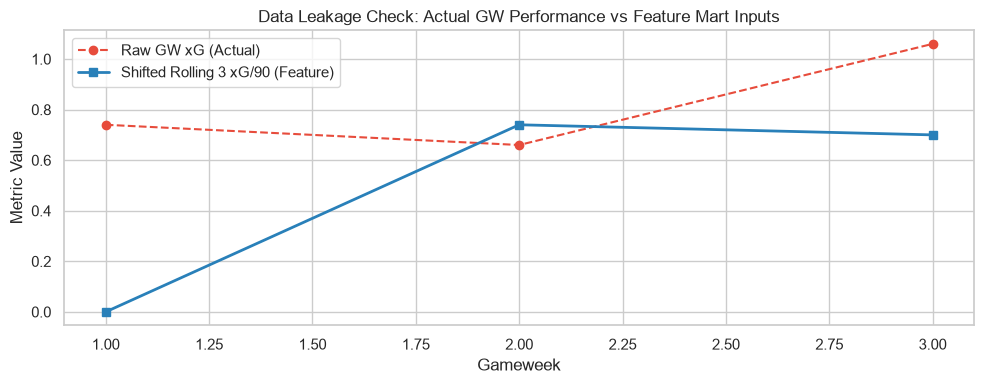

In [10]:
# Select Haaland (or any key player) to inspect alignment
sample_player = feature_mart[feature_mart["player_name"].str.contains("Haaland", case=False, na=False)].sort_values("gw")

inspect_cols = ["gw", "minutes", "xG", "rolling_min_3", "rolling_xG_90_3"]
print("--- Haaland Gameweek Features Inspection ---")
print(sample_player[inspect_cols].head(8).to_string(index=False))

# Plot raw xG vs Shifted Rolling xG 90
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample_player["gw"], sample_player["xG"], marker="o", label="Raw GW xG (Actual)", color="#e74c3c", linestyle="--")
ax.plot(sample_player["gw"], sample_player["rolling_xG_90_3"], marker="s", label="Shifted Rolling 3 xG/90 (Feature)", color="#2980b9", linewidth=2)
ax.set_title("Data Leakage Check: Actual GW Performance vs Feature Mart Inputs")
ax.set_xlabel("Gameweek")
ax.set_ylabel("Metric Value")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Persisting Feature Mart to SQLite

We replace or populate `fact_player_features` table inside `data/fpl.db` to serve as the direct feature store for `predict_xp.py`.

In [11]:
feature_mart_clean = feature_mart.copy()

# Save into SQLite database
feature_mart_clean.to_sql("fact_player_features", conn, if_exists="replace", index=False)
print("Successfully written feature mart to SQLite table 'fact_player_features'!")

# Verify row counts
row_count = pd.read_sql("SELECT COUNT(*) FROM fact_player_features;", conn).iloc[0, 0]
print(f"Total records stored in 'fact_player_features': {row_count}")

conn.close()

Successfully written feature mart to SQLite table 'fact_player_features'!
Total records stored in 'fact_player_features': 1890


## Key Takeaways from Feature Engineering

1. **Strict Temporal Alignment**: By applying `.shift(1)` on grouped player series, features at Gameweek $N$ contain zero future information from Gameweek $N$.
2. **Robust Per-90 Calculation**: Ratio-of-sums windowing prevents small-minute substitute appearances from distorting $xG_{90}$ and $xA_{90}$ baselines.
3. **Feature Persistence**: Cleaned feature store is persisted to `fact_player_features`, decoupling feature engineering logic from point prediction modeling.

---
**Next Step**: Proceed to `notebooks/03_modeling_and_xp.ipynb` to evaluate the Poisson modeling engine and simulate expected points.